# Gravity as First Implementation Output — Source-to-Sign Test

This notebook performs the next exact step in the gravity branch.

We already derived that if the exterior potential is

$$
\Phi(r) = -\frac{\mu}{r} + \frac{A}{r^2},
$$

then the perihelion shift is

$$
\Delta\varpi
=
2\pi\left(\frac{1}{\sqrt{1+2A/h^2}}-1\right)
\approx
-\,\frac{2\pi A}{\mu a(1-e^2)}
$$

for small correction.

That gave a hard sign constraint:

- $A<0$ gives **prograde** precession,
- $A>0$ gives **retrograde** precession.

So the next question is unavoidable:

$$
\boxed{
\text{what sign does }A\text{ actually get from the current cut-density source model?}
}
$$


## 1. Current source model from the repaired gravity branch

The repaired branch used an exterior cut-density tail

$$
\rho_\Gamma(r) = \frac{\eta}{r^4},
\qquad r \ge r_0,
$$

with coupling

$$
\rho_{\mathrm{eff}} = \rho_m + \alpha \rho_\Gamma.
$$

Integrating this tail outside the compact source gives the additional potential term

$$
\Phi_{\mathrm{tail}}(r)
=
\frac{2\pi G \alpha \eta}{r^2}.
$$

So the correction coefficient is

$$
\boxed{
A = 2\pi G \alpha \eta.
}
$$


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

G = 1.0

def A_from_tail(alpha, eta, G=1.0):
    return 2*np.pi*G*alpha*eta

grid = []
for alpha in [-1.0, -0.3, -0.1, 0.1, 0.3, 1.0]:
    for eta in [-1.0, -0.3, -0.1, 0.1, 0.3, 1.0]:
        A = A_from_tail(alpha, eta, G=G)
        sign = "negative" if A < 0 else "positive" if A > 0 else "zero"
        effect = "prograde" if A < 0 else "retrograde" if A > 0 else "none"
        grid.append({
            "alpha": alpha,
            "eta": eta,
            "A": A,
            "A_sign": sign,
            "precession_sign": effect,
        })

sign_df = pd.DataFrame(grid)
sign_df.head(12)


,alpha,eta,A,A_sign,precession_sign
0,-1.0,-1.0,6.283185,positive,retrograde
1,-1.0,-0.3,1.884956,positive,retrograde
2,-1.0,-0.1,0.628319,positive,retrograde
3,-1.0,0.1,-0.628319,negative,prograde
4,-1.0,0.3,-1.884956,negative,prograde
5,-1.0,1.0,-6.283185,negative,prograde
6,-0.3,-1.0,1.884956,positive,retrograde
7,-0.3,-0.3,0.565487,positive,retrograde
8,-0.3,-0.1,0.188496,positive,retrograde
9,-0.3,0.1,-0.188496,negative,prograde


For the physically natural case in the current branch,

$$
\alpha > 0,
\qquad
\eta > 0,
$$

we get

$$
\boxed{
A = 2\pi G \alpha \eta > 0.
}
$$

That means:

$$
\boxed{
\text{the current positive tail model predicts retrograde precession.}
}
$$


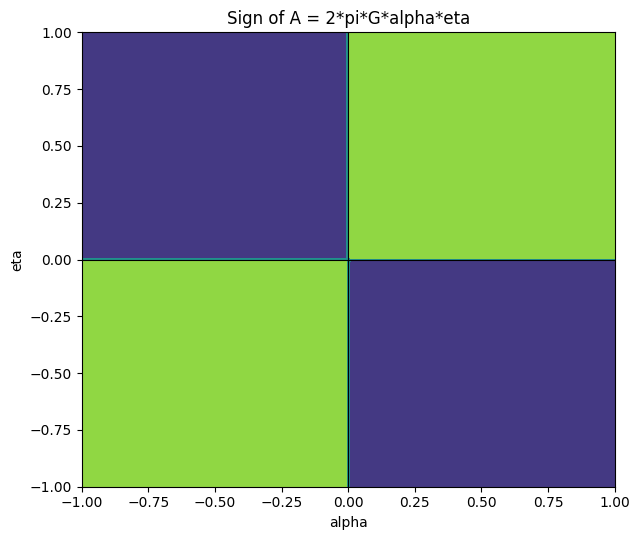

In [2]:

alphas = np.linspace(-1, 1, 201)
etas = np.linspace(-1, 1, 201)
AA, EE = np.meshgrid(alphas, etas)
Avals = A_from_tail(AA, EE, G=1.0)

plt.figure(figsize=(6.5,5.5))
plt.contourf(AA, EE, np.sign(Avals), levels=[-1.5,-0.5,0.5,1.5])
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("alpha")
plt.ylabel("eta")
plt.title("Sign of A = 2*pi*G*alpha*eta")
plt.tight_layout()
plt.show()


The sign map is simple:

- if $\alpha$ and $\eta$ have the **same sign**, then $A>0$ and the correction is retrograde,
- if they have **opposite signs**, then $A<0$ and the correction is prograde.

So the notebook has now forced a real decision.

If the gravity-as-output model is to reproduce prograde anomalous precession with this potential structure, then it must do one of the following:

1. produce an effective negative $A$,
2. flip the sign of one of the couplings,
3. or abandon the bare additive $+A/r^2$ potential as the true first observable route.


## 2. Small-correction orbital shift from the current source model

Substituting

$$
A = 2\pi G \alpha \eta
$$

into the small-correction law gives

$$
\boxed{
\Delta\varpi
\approx
-\frac{4\pi^2 G \alpha \eta}{\mu a(1-e^2)}.
}
$$

So for the current positive-tail source:

$$
\alpha > 0,\ \eta > 0
\quad\Rightarrow\quad
\Delta\varpi < 0.
$$

That is retrograde.

This means the current scalar-tail version is not compatible with a prograde anomaly unless its sign logic is changed.


In [3]:

def delta_varpi_small_from_source(alpha, eta, mu=1.0, a=1.0, e=0.2, G=1.0):
    A = A_from_tail(alpha, eta, G=G)
    return -(2*np.pi*A)/(mu*a*(1-e**2))

example_rows = []
for alpha, eta in [(0.3,0.3), (0.3,-0.3), (-0.3,0.3), (-0.3,-0.3)]:
    dvarpi = delta_varpi_small_from_source(alpha, eta, mu=1.0, a=1.0, e=0.2, G=1.0)
    example_rows.append({
        "alpha": alpha,
        "eta": eta,
        "delta_varpi_small": dvarpi,
        "direction": "prograde" if dvarpi > 0 else "retrograde" if dvarpi < 0 else "none"
    })

examples_df = pd.DataFrame(example_rows)
examples_df


,alpha,eta,delta_varpi_small,direction
0,0.3,0.3,-3.701102,retrograde
1,0.3,-0.3,3.701102,prograde
2,-0.3,0.3,3.701102,prograde
3,-0.3,-0.3,-3.701102,retrograde


## 3. The hard conclusion

The simplest current source model,

$$
\rho_\Gamma(r)=\frac{\eta}{r^4},
\qquad
\Phi_{\mathrm{tail}}(r)=\frac{2\pi G\alpha\eta}{r^2},
$$

does **not** automatically support prograde precession if both coupling and tail amplitude are positive.

So the branch is now forced to sharpen:

### Route A — sign-flipped source
Some effective coupling must enter with opposite sign so that

$$
A<0.
$$

### Route B — metric route
The observable correction may not be representable as a simple additive $+A/r^2$ potential, even if the deeper source is positive.

### Route C — different exterior kernel
The reflected boundary law may generate a different exterior structure than the simple positive scalar tail.


## 4. Why this is still progress

This is not a failure.
It is exactly what we needed.

Before this notebook, the gravity-as-output branch had a plausible architecture but no sign discipline.

Now it has one:

$$
\boxed{
\text{the naive positive scalar tail produces the wrong precession sign for a prograde anomaly.}
}
$$

That means the next step is no longer vague philosophy.
It is a very sharp modeling task:

$$
\boxed{
\text{find the first implementation-output kernel that gives } A<0 \text{ effectively,}
}
$$

or prove that the correction must be metric rather than potential-additive.


## 5. Best current read of the gravity branch

The architecture still holds:

$$
(\mathcal B,\mathcal T,\mathcal R)
\to
\rho_\Gamma
\to
v_{\mathrm{eff}}
\to
\kappa
\to
\text{gravity outputs}.
$$

What has now changed is this:

$$
\boxed{
\text{the first simple exterior scalar tail is too naive.}
}
$$

So the gravity branch is no longer "what if maybe."
It now has a genuine discriminator:

- **positive scalar tail** $\to$ retrograde
- **observed prograde anomaly** $\to$ requires a different effective sign structure


## 6. Next exact move

The next continuation should be one of these two:

### Option 1
Derive an exterior **reflection kernel** from the boundary model and see whether it naturally yields an effective negative $A$.

### Option 2
Write the first metric-like correction directly and compute the perihelion sign there, instead of forcing everything into a scalar additive potential.

At this point, both are legitimate. The scalar-tail proxy has done its job by exposing the sign constraint.
